# yfinance EDA interactivo (entrada de tickers)

Este notebook te pide la **nomenclatura de tickers** (símbolos) y descarga los mismos datos que en el notebook `01_yfinance_eda.ipynb`:

- OHLCV histórico (Open/High/Low/Close/Adj Close/Volume)
- Conversión a formato **largo** (Date, Ticker, variables)
- Reporte de calidad (nulos, duplicados)
- Estadística descriptiva
- Retornos, volatilidad rolling, drawdown, correlación y una señal simple de medias móviles

## Pistas de nomenclatura (Yahoo Finance / yfinance)

- Acciones/ETFs USA: `AAPL`, `MSFT`, `SPY`, `QQQ`
- Índices: suelen empezar por `^` → `^GSPC` (S&P 500), `^VIX`
- FX: suelen acabar en `=X` → `EURUSD=X`
- Crypto: suele ser `BTC-USD`, `ETH-USD`


In [1]:
# Si lo necesitas:
# !pip install yfinance pandas numpy matplotlib

from pathlib import Path
import time
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)


In [5]:
# === Entrada de usuario ===
# Ejemplo: SPY, QQQ, ^GSPC, ^VIX
tickers_in = input("Introduce tickers separados por coma (p.ej. SPY, QQQ, ^GSPC, ^VIX): ").strip()
if not tickers_in:
    tickers_in = "SPY, QQQ, ^GSPC, ^VIX"

TICKERS = [t.strip() for t in tickers_in.split(",") if t.strip()]
print("Tickers:", TICKERS)

START = input("START (YYYY-MM-DD) [2000-01-01]: ").strip() or "2000-01-01"
END = input("END (YYYY-MM-DD) [vacío = hasta hoy]: ").strip() or None
INTERVAL = input("INTERVAL (1d,1h,1wk,...) [1d]: ").strip() or "1d"

print("START:", START, "| END:", END, "| INTERVAL:", INTERVAL)


Introduce tickers separados por coma (p.ej. SPY, QQQ, ^GSPC, ^VIX): ^IBEX
Tickers: ['^IBEX']
START (YYYY-MM-DD) [2000-01-01]: 
END (YYYY-MM-DD) [vacío = hasta hoy]: 
INTERVAL (1d,1h,1wk,...) [1d]: 1d
START: 2000-01-01 | END: None | INTERVAL: 1d


In [6]:
# Descarga multi-ticker
# group_by='ticker' devuelve columnas por ticker cuando hay múltiples símbolos.
raw = yf.download(
    tickers=TICKERS,
    start=START,
    end=END,
    interval=INTERVAL,
    group_by="ticker",
    auto_adjust=False,
    threads=True,
)

raw.tail()


[*********************100%***********************]  1 of 1 completed


Ticker             ^IBEX                                                                   
Price               Open          High           Low         Close     Adj Close     Volume
Date                                                                                       
2026-02-27  18443.599609  18573.800781  18306.800781  18360.800781  18360.800781          0
2026-03-02  17830.500000  17981.500000  17768.199219  17878.900391  17878.900391          0
2026-03-03  17600.699219  17621.699219  16904.400391  17062.400391  17062.400391          0
2026-03-04  17062.400391  17555.699219  16881.199219  17487.000000  17487.000000          0
2026-03-05  17496.400391  17502.699219  17377.599609  17444.500000  17444.500000  107858866

In [ ]:
# Guarda un CSV por ticker en data/raw
def save_raw_per_ticker(raw_df: pd.DataFrame, tickers: list[str], out_dir: Path, interval: str) -> None:
    if isinstance(raw_df.columns, pd.MultiIndex):
        # columnas tipo (Ticker, Field)
        for t in tickers:
            cols = [c for c in raw_df.columns if c[0] == t]
            if not cols:
                continue
            sub = raw_df[cols].copy()
            sub.columns = [c[1] for c in cols]
            sub.to_csv(out_dir / f"{t.replace('^','_')}_{interval}.csv", index=True)
    else:
        # single ticker
        raw_df.to_csv(out_dir / f"{tickers[0].replace('^','_')}_{interval}.csv", index=True)

save_raw_per_ticker(raw, TICKERS, RAW_DIR, INTERVAL)
print("Guardado en:", RAW_DIR.resolve())


Guardado en: C:\Users\usuario\data\raw


In [7]:
def to_long_ohlcv(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Convierte el DataFrame de yfinance a formato largo:
    columnas: [Date, Ticker, Open, High, Low, Close, Adj_Close, Volume]
    """
    if isinstance(raw_df.columns, pd.MultiIndex):
        pieces = []
        for t in sorted(set([c[0] for c in raw_df.columns])):
            sub = raw_df[t].copy()
            sub = sub.rename(columns={"Adj Close": "Adj_Close"})
            sub["Ticker"] = t
            pieces.append(sub.reset_index())
        df = pd.concat(pieces, ignore_index=True)
    else:
        df = raw_df.copy().reset_index()
        df = df.rename(columns={"Adj Close": "Adj_Close"})
        df["Ticker"] = "SINGLE"
    # Orden columnas
    cols = ["Date", "Ticker"] + [c for c in df.columns if c not in ["Date", "Ticker"]]
    return df[cols]

df_long = to_long_ohlcv(raw)
df_long.tail()


Price,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
6653,2026-02-27,^IBEX,18443.599609,18573.800781,18306.800781,18360.800781,18360.800781,0
6654,2026-03-02,^IBEX,17830.500000,17981.500000,17768.199219,17878.900391,17878.900391,0
6655,2026-03-03,^IBEX,17600.699219,17621.699219,16904.400391,17062.400391,17062.400391,0
6656,2026-03-04,^IBEX,17062.400391,17555.699219,16881.199219,17487.000000,17487.000000,0
6657,2026-03-05,^IBEX,17496.400391,17502.699219,17377.599609,17444.500000,17444.500000,107858866


In [8]:
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(3),
        "n_unique": df.nunique(dropna=True),
    })
    return rep.sort_values(["pct_missing", "n_missing"], ascending=False)

# Duplicados por (Date, Ticker)
dups = df_long.duplicated(subset=["Date", "Ticker"]).sum()
print("Duplicados (Date,Ticker):", int(dups))

data_quality_report(df_long)

Duplicados (Date,Ticker): 0


,dtype,n_missing,pct_missing,n_unique
Price,,,,
Date,datetime64[ns],0,0.0,6658
Ticker,object,0,0.0,1
Open,float64,0,0.0,6361
High,float64,0,0.0,6324
Low,float64,0,0.0,6325
Close,float64,0,0.0,6301
Adj_Close,float64,0,0.0,6449
Volume,int64,0,0.0,5206


In [ ]:
# Estadística descriptiva por ticker
numeric_cols = [c for c in df_long.columns if c not in ["Date", "Ticker"]]

desc = (
    df_long
    .groupby("Ticker")[numeric_cols]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)
desc

Price     Open                                                                                                      High             \
         count       mean        std       min        1%        5%       50%         95%         99%         max   count       mean   
Ticker                                                                                                                                
AAPL    4570.0  73.191626  76.022637  2.835357  3.228757  4.955339  32.86375  228.136997  269.865795  286.200012  4570.0  73.979324   

Price                                                                                             Low                                 \
              std       min       1%        5%        50%         95%         99%         max   count      mean        std       min   
Ticker                                                                                                                                 
AAPL    76.841254  2.928571  3.33345  5.007947  33.088749  230.160004  272.971194  288.619995  4570.0  72.45088  75.276541  2.792857   

Price                                                                       Close                                                      \
              1%        5%        50%         95%         99%         max   count       mean        std       min        1%        5%   
Ticker                                                                                                                                  
AAPL    3.174557  4.859535  32.546251  225.853999  267.218487  283.299988  4570.0  73.246444  76.092053  2.792857  3.242303  4.971286   

Price                                                Adj_Close                                                                             \
             50%         95%         99%         max     count       mean        std       min        1%        5%        50%         95%   
Ticker                                                                                                                                      
AAPL    32.91375  228.123498  269.844395  286.190002    4570.0  71.025467  76.207137  2.343106  2.720177  4.170731  29.534769  226.860248   

Price                          Volume                                                                                             \
              99%         max   count          mean           std         min          1%          5%          50%           95%   
Ticker                                                                                                                             
AAPL    269.34032  285.922455  4570.0  2.872216e+08  3.211391e+08  17910600.0  34072187.0  44655905.0  151113100.0  9.263979e+08   

Price                               
                 99%           max  
Ticker                              
AAPL    1.570512e+09  3.372970e+09

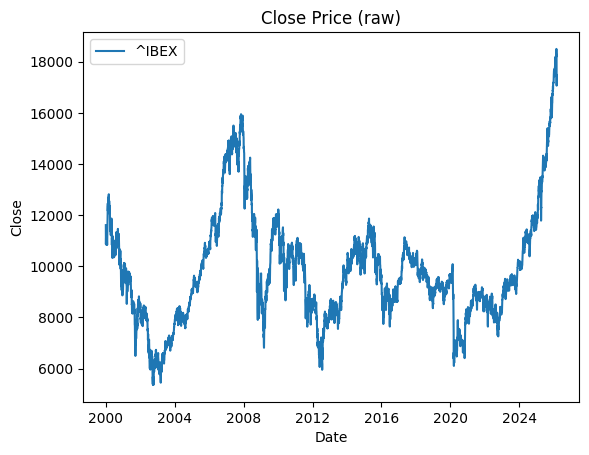

In [9]:
def plot_close_prices(raw_df: pd.DataFrame, tickers: list[str], title: str = "Close Price"):
    plt.figure()
    if isinstance(raw_df.columns, pd.MultiIndex):
        for t in tickers:
            if (t, "Close") in raw_df.columns:
                plt.plot(raw_df.index, raw_df[(t, "Close")], label=t)
    else:
        plt.plot(raw_df.index, raw_df["Close"], label=tickers[0])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.legend()
    plt.show()

plot_close_prices(raw, TICKERS, title="Close Price (raw)")

In [10]:
def get_close_wide(raw_df: pd.DataFrame, tickers: list[str]) -> pd.DataFrame:
    if isinstance(raw_df.columns, pd.MultiIndex):
        close = pd.DataFrame({t: raw_df[(t, "Close")] for t in tickers if (t, "Close") in raw_df.columns})
    else:
        close = raw_df[["Close"]].rename(columns={"Close": tickers[0]})
    return close

close = get_close_wide(raw, TICKERS)

# Rendimientos
ret = close.pct_change()
logret = np.log(close).diff()

# Volatilidad rolling (anualizada aprox para daily)
ROLL = 21  # ~1 mes bursátil si interval=1d
scale = 252 if INTERVAL.endswith("d") else 252  # simplificación
vol = logret.rolling(ROLL).std() * np.sqrt(scale)

close.tail(), logret.tail(), vol.tail()


(                   ^IBEX
 Date                    
 2026-02-27  18360.800781
 2026-03-02  17878.900391
 2026-03-03  17062.400391
 2026-03-04  17487.000000
 2026-03-05  17444.500000,
                ^IBEX
 Date                
 2026-02-27 -0.007369
 2026-03-02 -0.026597
 2026-03-03 -0.046744
 2026-03-04  0.024581
 2026-03-05 -0.002433,
                ^IBEX
 Date                
 2026-02-27  0.165093
 2026-03-02  0.184055
 2026-03-03  0.239000
 2026-03-04  0.257153
 2026-03-05  0.257149)

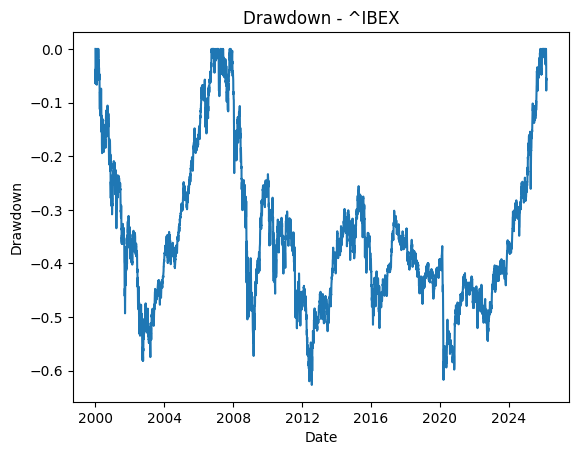

In [11]:
# Drawdown
def compute_drawdown(price: pd.Series) -> pd.DataFrame:
    cummax = price.cummax()
    dd = price / cummax - 1.0
    return pd.DataFrame({"price": price, "cummax": cummax, "drawdown": dd})

ticker_focus = TICKERS[0]
dd = compute_drawdown(close[ticker_focus].dropna())

plt.figure()
plt.plot(dd.index, dd["drawdown"])
plt.title(f"Drawdown - {ticker_focus}")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()


In [12]:
# Correlación de log-returns
corr = logret.dropna().corr()
corr

,^IBEX
^IBEX,1.0


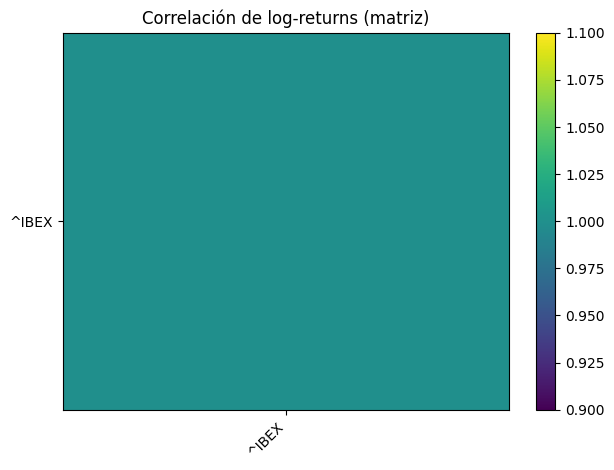

In [13]:
# Heatmap simple con matplotlib (sin seaborn)
plt.figure()
plt.imshow(corr.values, aspect="auto")
plt.title("Correlación de log-returns (matriz)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

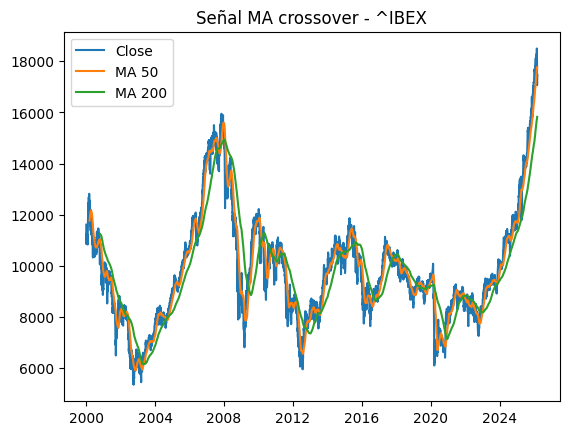

In [14]:
# Señal simple: cruce de medias (demo)
SHORT = 50
LONG = 200

if len(close.columns) > 0:
    ma_s = close[ticker_focus].rolling(SHORT).mean()
    ma_l = close[ticker_focus].rolling(LONG).mean()
    signal = (ma_s > ma_l).astype(int)

    plt.figure()
    plt.plot(close.index, close[ticker_focus], label="Close")
    plt.plot(ma_s.index, ma_s, label=f"MA {SHORT}")
    plt.plot(ma_l.index, ma_l, label=f"MA {LONG}")
    plt.title(f"Señal MA crossover - {ticker_focus}")
    plt.legend()
    plt.show()

In [ ]:
# Resumen final (retorno/volatilidad anualizada aprox)
summary_rows = []
for t in close.columns:
    s = close[t].dropna()
    if len(s) < 300:
        continue
    lr = np.log(s).diff().dropna()
    ann_ret = lr.mean() * 252
    ann_vol = lr.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    summary_rows.append({
        "Ticker": t,
        "n_obs": int(len(s)),
        "ann_log_return": float(ann_ret),
        "ann_vol": float(ann_vol),
        "sharpe_like": float(sharpe),
        "last_close": float(s.iloc[-1]),
    })

pd.DataFrame(summary_rows).sort_values("sharpe_like", ascending=False)


,Ticker,n_obs,ann_log_return,ann_vol,sharpe_like,last_close
0,AAPL,4570,0.200487,0.310091,0.646543,263.75
